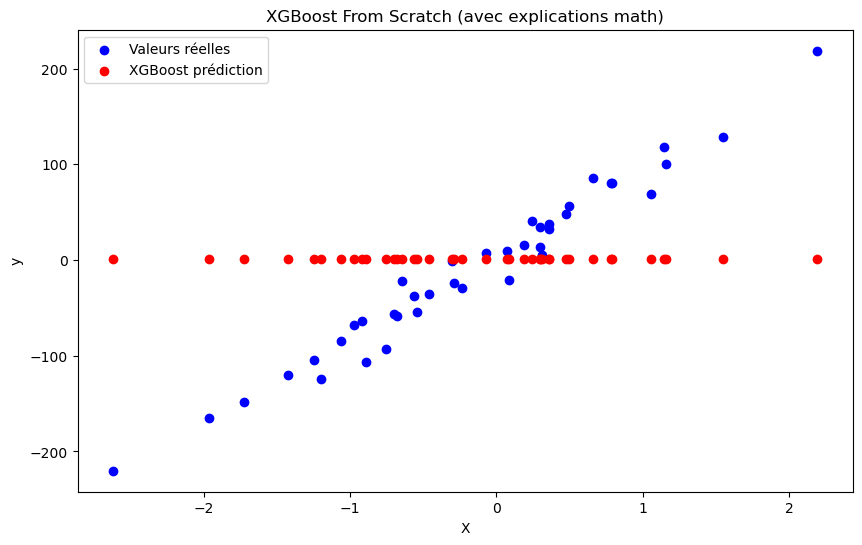

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# ============================================================
# 1. CRÉATION DU DATASET
# ============================================================

# On crée un dataset artificiel pour un problème de régression.
# Chaque exemple est (X, y) où :
# - X = variable d'entrée
# - y = valeur cible

# FORMULE GÉNÉRALE :
# y = f(X) + bruit

X, y = make_regression(
    n_samples=200,     # nombre d'exemples
    n_features=1,       # une seule variable
    noise=15,           # bruit (simulation réalité)
    random_state=42
)

# On divise les données en train / test
# train = apprentissage
# test = évaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# 2. WEAK LEARNER (ARBRE TRÈS SIMPLIFIÉ)
# ============================================================

class SimpleTree:

    def fit(self, X, y):
        # ====================================================
        # BUT :
        # trouver une constante w qui minimise l'erreur MSE
        #
        # PROBLÈME :
        # min Σ (y_i - w)^2
        #
        # SOLUTION ANALYTIQUE :
        # w = moyenne(y)
        # ====================================================
        self.value = np.mean(y)

    def predict(self, X):
        # Chaque input reçoit la même valeur (feuille unique)
        return np.ones(len(X)) * self.value


# ============================================================
# 3. XGBOOST (VERSION SIMPLIFIÉE)
# ============================================================

class XGBoostScratch:

    def __init__(self, n_estimators=10, learning_rate=0.1):

        # nombre d'arbres
        self.n_estimators = n_estimators

        # η (eta) = learning rate
        # contrôle l'importance de chaque arbre
        self.learning_rate = learning_rate

        # stockage des arbres
        self.trees = []

    def fit(self, X, y):

        # ====================================================
        # INITIALISATION DU MODÈLE
        #
        # F0(x) = 0 (prédiction initiale)
        # ====================================================
        self.pred = np.zeros(len(y))

        # ====================================================
        # BOUCLE BOOSTING
        # on ajoute un arbre à chaque itération
        # ====================================================
        for i in range(self.n_estimators):

            # ====================================================
            # 1. CALCUL DES RESIDUALS
            # ====================================================
            #
            # FORMULE :
            # r_i = y_i - F(x_i)
            #
            # INTERPRÉTATION :
            # erreur du modèle actuel
            # ====================================================
            residuals = y - self.pred

            # ====================================================
            # 2. APPRENTISSAGE D'UN NOUVEL ARBRE
            # ====================================================
            #
            # BUT :
            # approximer les residuals
            #
            # h_m(x) ≈ r_i
            # ====================================================
            tree = SimpleTree()
            tree.fit(X, residuals)

            # ====================================================
            # 3. PRÉDICTION DE CET ARBRE
            # ====================================================
            h_m = tree.predict(X)

            # ====================================================
            # 4. MISE À JOUR DU MODÈLE GLOBAL
            # ====================================================
            #
            # FORMULE BOOSTING :
            #
            # F_m(x) = F_{m-1}(x) + η * h_m(x)
            #
            # où :
            # - F_m(x) = nouveau modèle
            # - η = learning rate
            # - h_m(x) = nouvel arbre
            # ====================================================
            self.pred += self.learning_rate * h_m

            # stockage de l'arbre
            self.trees.append(tree)

    def predict(self, X):

        # ====================================================
        # PRÉDICTION FINALE :
        #
        # F(x) = Σ η * h_m(x)
        # ====================================================
        pred = np.zeros(len(X))

        for tree in self.trees:
            pred += self.learning_rate * tree.predict(X)

        return pred


# ============================================================
# 4. ENTRAÎNEMENT DU MODÈLE
# ============================================================

model = XGBoostScratch(
    n_estimators=20,   # nombre d'arbres
    learning_rate=0.1  # taille des corrections
)

model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


# ============================================================
# 5. VISUALISATION
# ============================================================

plt.figure(figsize=(10,6))

# points réels
plt.scatter(
    X_test,
    y_test,
    label="Valeurs réelles",
    color="blue"
)

# prédictions du modèle
plt.scatter(
    X_test,
    y_pred,
    label="XGBoost prédiction",
    color="red"
)

plt.title("XGBoost From Scratch (avec explications math)")
plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.show()